# Análisis Exploratorio y Preprocesamiento de Datos (Dual-Engine)
Este sistema pionero consta de dos ejes arquitectónicos:
1. **Módulo de Consulta Normativa (NLP):** Encargado del análisis profundo de los manuales, directivas y reglas aeronáuticas (reglas de vuelo, licencias, estándares) de la DGAC y la OACI.
2. **Módulo Predictivo de Riesgo Clínico (Tabular):** Enfocado en predecir patologías subyacentes críticas (como la Diabetes y afecciones coronarias) que inhabiliten médicamente a un piloto, procesadas con algoritmos clásicos de Machine Learning.

A continuación, ejecutaremos la fase de *Data Understanding* y *Data Preparation* (CRISP-DM) combinando ambos motores.

---
## SECCIÓN A: Módulo Documental (NLP)
---

C:\Users\castr\AppData\Local\Temp\ipykernel_25864\1286752344.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='fuente', order=df['fuente'].value_counts().index, palette='Blues_r')


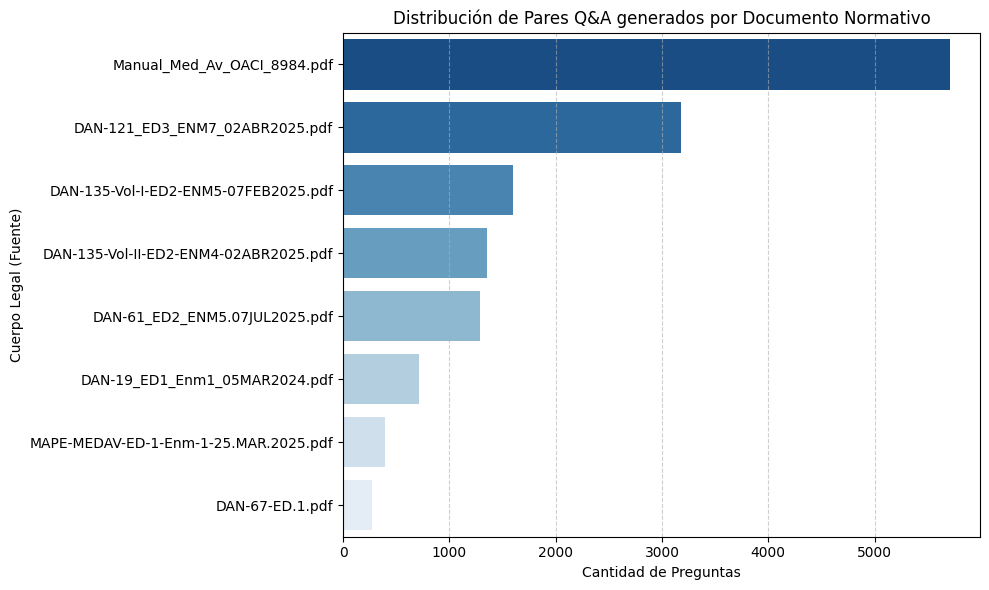

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

# Carga de datos JSONL generados sintéticamente
datos = []
ruta_dataset = "../dataset_sintetico/mega_dataset_aeronautico.jsonl"

with open(ruta_dataset, 'r', encoding='utf-8') as f:
    for linea in f:
        datos.append(json.loads(linea))

df = pd.DataFrame(datos)

# Countplot horizontal de las fuentes
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='fuente', order=df['fuente'].value_counts().index, palette='Blues_r')
plt.title('Distribución de Pares Q&A generados por Documento Normativo')
plt.xlabel('Cantidad de Preguntas')
plt.ylabel('Cuerpo Legal (Fuente)')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

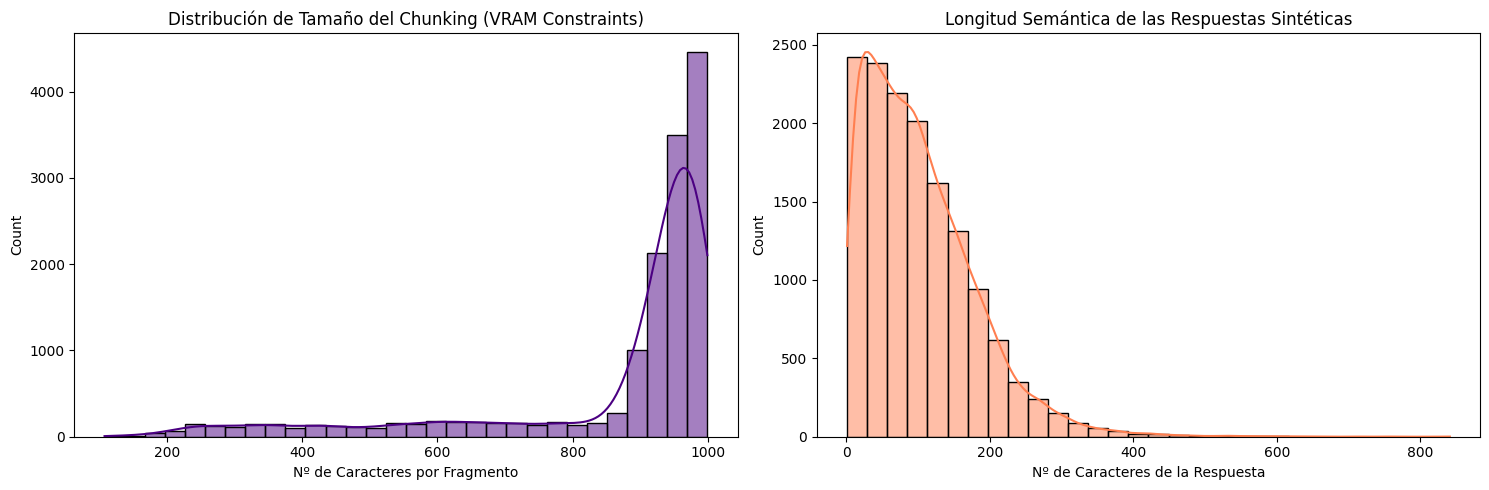

In [2]:
# Análisis de Longitud (Caracteres) de los fragmentos
df['longitud_contexto'] = df['contexto_original'].apply(len)
df['longitud_respuesta'] = df['respuesta'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['longitud_contexto'], bins=30, ax=axes[0], color='indigo', kde=True)
axes[0].set_title('Distribución de Tamaño del Chunking (VRAM Constraints)')
axes[0].set_xlabel('Nº de Caracteres por Fragmento')

sns.histplot(df['longitud_respuesta'], bins=30, ax=axes[1], color='coral', kde=True)
axes[1].set_title('Longitud Semántica de las Respuestas Sintéticas')
axes[1].set_xlabel('Nº de Caracteres de la Respuesta')

plt.tight_layout()
plt.show()

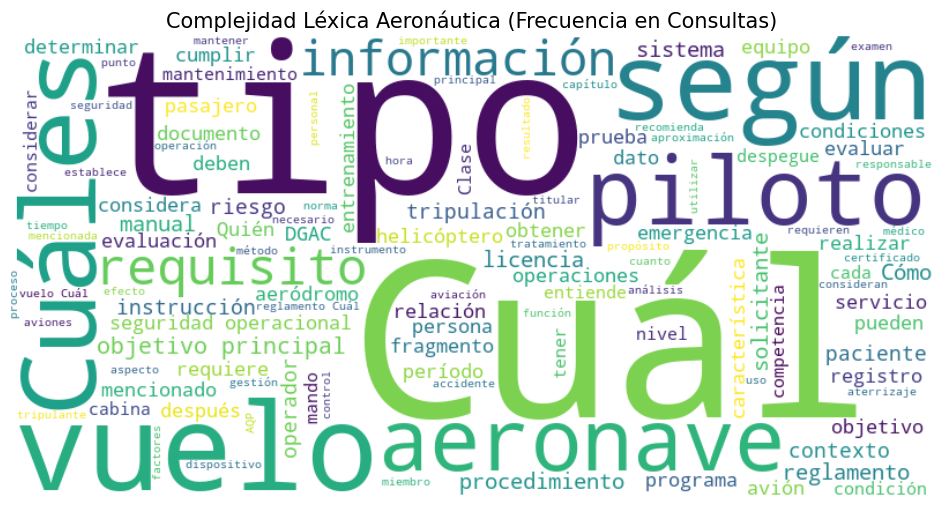

In [3]:
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

stop_words_es = set(stopwords.words('spanish'))
stop_words_es.update(['si', 'debe', 'ser', 'así', 'caso', 'puede', 'cualquier', 'parte'])

texto_preguntas = " ".join(df['pregunta'].tolist())

wordcloud = WordCloud(width=800, height=400, background_color='white', 
                      colormap='viridis', stopwords=stop_words_es, max_words=120).generate(texto_preguntas)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Complejidad Léxica Aeronáutica (Frecuencia en Consultas)', fontsize=15)
plt.show()

Invocando a Motor Embeddings de Ollama para 768 dimensiones...


  0%|          | 0/2000 [00:00<?, ?it/s]

Ejecutando Reducción Dimensional PCA...
Varianza explicada matemáticamente por Componentes PC1/PC2: 6.88%, 4.25%


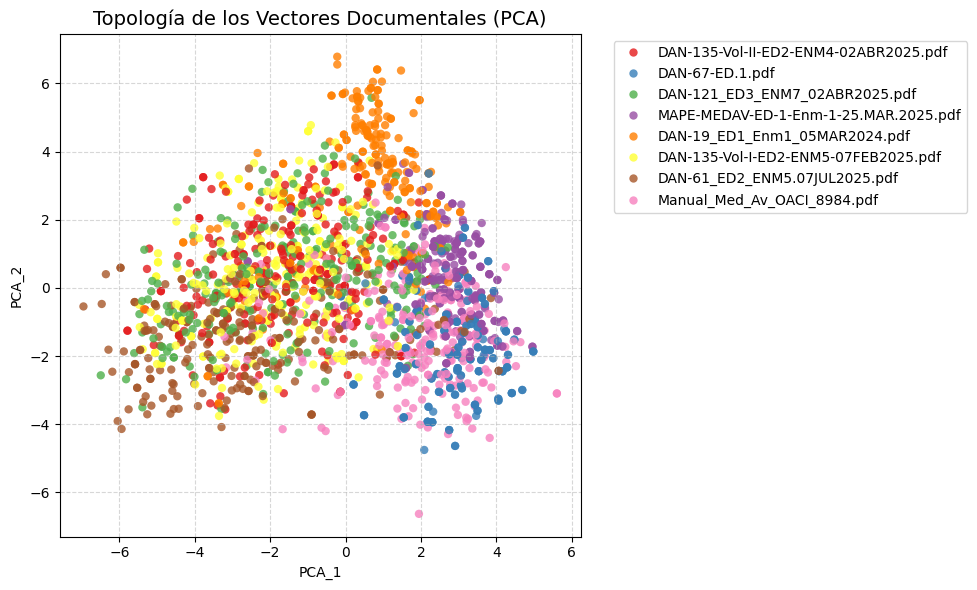

In [4]:
import numpy as np
import umap
from sklearn.decomposition import PCA
from ollama import Client
from tqdm.notebook import tqdm

cliente = Client(host='http://localhost:11434')
modelo_embeddings = "nomic-embed-text"

# Muestreo estratificado robusto a 2000 entidades garantizando presencia de columnas (Pandas >= 2.x)
muestras = []
for nombre, grupo in df.groupby('fuente'):
    muestras.append(grupo.sample(min(len(grupo), 300), random_state=42))
df_muestra = pd.concat(muestras).reset_index(drop=True)

if len(df_muestra) > 2000:
    df_muestra = df_muestra.sample(2000, random_state=42).reset_index(drop=True)

print("Invocando a Motor Embeddings de Ollama para 768 dimensiones...")
embeddings = []
for contexto in tqdm(df_muestra['contexto_original']):
    resp = cliente.embeddings(model=modelo_embeddings, prompt=contexto)
    embeddings.append(resp['embedding'])
matriz_embeddings = np.array(embeddings)

print("Ejecutando Reducción Dimensional PCA...")
pca = PCA(n_components=2, random_state=42)
embeddings_pca = pca.fit_transform(matriz_embeddings)

df_muestra['PCA_1'] = embeddings_pca[:, 0]
df_muestra['PCA_2'] = embeddings_pca[:, 1]
varianza = pca.explained_variance_ratio_

print(f"Varianza explicada matemáticamente por Componentes PC1/PC2: {varianza[0]*100:.2f}%, {varianza[1]*100:.2f}%")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_muestra, x='PCA_1', y='PCA_2', hue='fuente', palette='Set1', alpha=0.8, edgecolor='none')
plt.title('Topología de los Vectores Documentales (PCA)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
## SECCIÓN B: Módulo Predictivo (Estructurado)
---

In [5]:
# ==========================================
# DATA QUALITY REPORT Y ANOMALÍAS
# ==========================================
import numpy as np

# Carga del repositorio clínico (Módulo Tabular)
ruta_csv = "../datos_crudos/diabetes_binary_health_indicators_BRFSS2015.csv"
df_tab = pd.read_csv(ruta_csv)

np.random.seed(42)

# Simulación de pérdida de datos tipo sensórica: Inyectar 2% de valores faltantes (NaN) en IMC
indices_nulos = np.random.choice(df_tab.index, size=int(len(df_tab) * 0.02), replace=False)
df_tab.loc[indices_nulos, 'BMI'] = np.nan

print("--- REPORTE DE CALIDAD DE DATOS (Data Quality) ---")
print(df_tab.info())
print("\nTotal de anomalías estructurales detectadas (Nulos por Columna):")
print(df_tab.isnull().sum()[df_tab.isnull().sum() > 0])

--- REPORTE DE CALIDAD DE DATOS (Data Quality) ---
<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   248607 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth     

In [6]:
# ==========================================
# PREPROCESAMIENTO CLÁSICO: K-NN y ESCALAMIENTO
# ==========================================
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

# Por tiempos de computo del EDA, trabajaremos sobre 50.000 observaciones de pilotos
df_tab_sample = df_tab.sample(50000, random_state=42).copy()

print(f"Ejecutando algoritmo K-NN para imputación multidimensional sobre {len(df_tab_sample)} instancias...")
imputador_knn = KNNImputer(n_neighbors=5)

# Como KNNImputer utiliza métricas de distancia, se evalúan los vecindarios
df_tab_sample[['BMI']] = imputador_knn.fit_transform(df_tab_sample[['BMI']])
print("Validación post-imputación matemática, Nulos restantes:", df_tab_sample['BMI'].isnull().sum())

print("Escalando las variables métricas continuas...")
escalador = StandardScaler()
df_tab_sample[['BMI', 'Age']] = escalador.fit_transform(df_tab_sample[['BMI', 'Age']])
print("Proceso Finalizado Exitosamente: 'BMI' y 'Age' estandarizados con media 0 y varianza 1.")

Ejecutando algoritmo K-NN para imputación multidimensional sobre 50000 instancias...
Validación post-imputación matemática, Nulos restantes: 0
Escalando las variables métricas continuas...
Proceso Finalizado Exitosamente: 'BMI' y 'Age' estandarizados con media 0 y varianza 1.


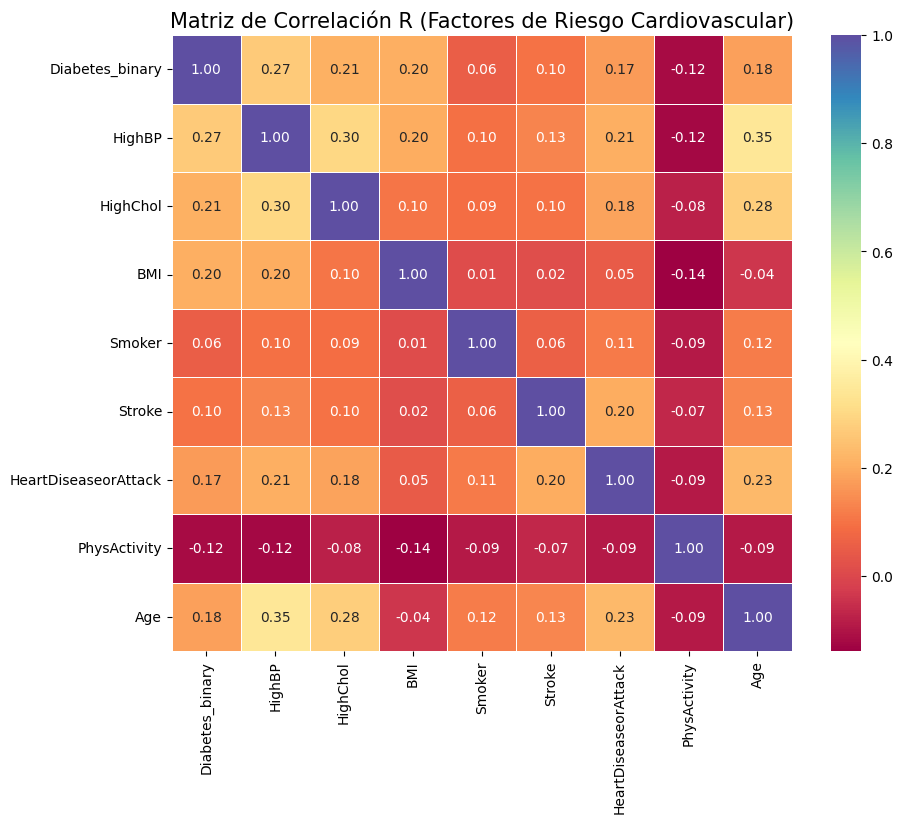

Transfiriendo contexto tabular a LLM (Cargando modelo local: mistral)...

🚀 CONCLUSIONES GENERADAS POR INTELIGENCIA ARTIFICIAL (MISTRAL):
---------------------------------------------------------------------------
 1. La correlación entre el desarrollo de diabetes y altos valores de presión arterial (HighBP) presenta una relación moderada, lo que sugiere que un aumento en la presión arterial puede incrementar el riesgo de diabetes en nuestros pilotos.
2. La correlación entre el desarrollo de diabetes y elevados niveles de colesterol (HighChol) también es moderada, lo que implica que los pilotos con altos niveles de colesterol pueden tener un mayor riesgo de padecer diabetes.
3. Los resultados muestran una relación inversa y modesta entre el desarrollo de diabetes y la actividad física (PhysActivity), lo que sugiere que los pilotos que realizan más ejercicio tienen menos probabilidades de padecer diabetes. Por otro lado, un mayor edad (Age) está asociado con un aumento moderado del ries

In [7]:
# ==========================================
# MATRIZ DE CORRELACIÓN + INFERENCIA LLM (MISTRAL)
# ==========================================
columnas_estudio = ['Diabetes_binary', 'HighBP', 'HighChol', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Age']
df_corr = df_tab_sample[columnas_estudio].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr, annot=True, cmap='Spectral', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación R (Factores de Riesgo Cardiovascular)', fontsize=15)
plt.show()

# Extraemos la correlación matemática específica a la enfermedad tratada
corr_diabetes = df_corr['Diabetes_binary'].to_dict()

prompt_medico = f"""
Actúa como un médico especialista de la Organización de Aviación Civil Internacional (OACI). Logramos derivar este diccionario JSON con las correlaciones de Pearson entre el desarrollo de 'Diabetes' y sub-factores en nuestros pilotos:
{corr_diabetes}

Reglas:
1. Analiza los números matemáticamente (ej. más de 0.2 es moderada, más de 0.6 es alta, y los signos negativos implican relaciones inversas proporcionales de protección).
2. Genera estrictamente 3 conclusiones en español, numeradas. No respondas nada más.
3. El vocabulario debe ser clínico y técnico aplicable a salud ocupacional.
"""

print("Transfiriendo contexto tabular a LLM (Cargando modelo local: mistral)...")
try:
    # Este proceso fusiona por primera vez Data estructurada con el raciocinio Generativo NLP
    resp = cliente.chat(model='mistral', messages=[{'role': 'user', 'content': prompt_medico}])
    print("\n🚀 CONCLUSIONES GENERADAS POR INTELIGENCIA ARTIFICIAL (MISTRAL):")
    print("-" * 75)
    print(resp['message']['content'])
    print("-" * 75)
except Exception as e:
    print(f"Error invadiendo la terminal Mistral: {e}")